In [1]:
# 📦 Cell 1: Environment Setup & Reproducibility
import os
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.sparse import load_npz
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Reproducibility seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE} | PyTorch: {torch.__version__}")

✅ Device: cuda | PyTorch: 2.10.0+cu128


In [2]:
# 📥 Cell 2: Load Artifacts, Data Preparation & Negative Sampling
import os
import pickle
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

ARTIFACT_DIR = 'bookbuddy_artifacts'

# Load train/val/test splits
train_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'train.parquet'))
val_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'val.parquet'))
test_df = pd.read_parquet(os.path.join(ARTIFACT_DIR, 'test.parquet'))

# Load mappings & metadata
with open(os.path.join(ARTIFACT_DIR, 'artifacts.pkl'), 'rb') as f:
    artifacts = pickle.load(f)

n_users = len(artifacts['user_map'])
n_books = len(artifacts['book_map'])

print(f"📊 Original Split sizes: Train={len(train_df):,} | Val={len(val_df):,} | Test={len(test_df):,}")
print(f"🔢 Matrix dims: {n_users:,} users × {n_books:,} books")

# ✅ FIX 1: Set threshold to 4 to capture meaningful positive interactions without extreme imbalance
THRESHOLD = 4
def to_implicit(df):
    df = df.copy()
    df['label'] = (df['rating'] >= THRESHOLD).astype(int)
    return df[['user_idx', 'book_idx', 'label']]

train_imp = to_implicit(train_df)
val_imp = to_implicit(val_df)
test_imp = to_implicit(test_df)

# ✅ FIX 2: Generate Unobserved Negative Samples
def add_negative_samples(df, num_items, num_negatives=4):
    print(f"🔄 Generating {num_negatives} negative samples per positive interaction...")

    # Track what items a user HAS interacted with so we don't accidentally sample them
    user_interacted = df.groupby('user_idx')['book_idx'].apply(set).to_dict()

    # We only generate negatives for the POSITIVE interactions to teach the model how to rank
    positives = df[df['label'] == 1]

    neg_users, neg_books, neg_labels = [], [], []

    # Generate random items the user hasn't seen
    for user in tqdm(positives['user_idx'], desc="Sampling Negatives"):
        interacted = user_interacted.get(user, set())
        for _ in range(num_negatives):
            while True:
                neg_item = random.randint(0, num_items - 1)
                if neg_item not in interacted:
                    break
            neg_users.append(user)
            neg_books.append(neg_item)
            neg_labels.append(0)  # Unobserved items act as negative signals

    neg_df = pd.DataFrame({
        'user_idx': neg_users,
        'book_idx': neg_books,
        'label': neg_labels
    })

    # Combine original data with new negative samples and shuffle
    combined_df = pd.concat([df, neg_df], ignore_index=True)
    return combined_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

# Apply negative sampling ONLY to the training set (Validation remains strictly ground truth)
train_imp_with_negs = add_negative_samples(train_imp, n_books, num_negatives=4)
print(f"📈 New Train size with negatives: {len(train_imp_with_negs):,}")

# PyTorch Dataset
class CF_Dataset(Dataset):
    def __init__(self, df):
        self.u = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.i = torch.tensor(df['book_idx'].values, dtype=torch.long)
        self.y = torch.tensor(df['label'].values, dtype=torch.float32)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.u[idx], self.i[idx], self.y[idx]

# DataLoaders
BATCH_SIZE = 2048
# Pass the new augmented dataframe to the train_loader
train_loader = DataLoader(CF_Dataset(train_imp_with_negs), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(CF_Dataset(val_imp), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(CF_Dataset(test_imp), batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders ready | Batches: Train={len(train_loader)}, Val={len(val_loader)}, Test={len(test_loader)}")

📊 Original Split sizes: Train=3,904,582 | Val=836,696 | Test=836,697
🔢 Matrix dims: 53,424 users × 8,726 books
🔄 Generating 4 negative samples per positive interaction...


Sampling Negatives:   0%|          | 0/2699122 [00:00<?, ?it/s]

📈 New Train size with negatives: 14,701,070
✅ DataLoaders ready | Batches: Train=7179, Val=409, Test=409


In [3]:
# 🏗️ Cell 3: MLP-CF Architecture & Training/Evaluation Functions
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Define MLP-CF Model
class MLP_CF(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=32, hidden_dims=[64, 32], dropout=0.3):
        super(MLP_CF, self).__init__()
        self.user_embed = nn.Embedding(num_users, embed_dim)
        self.item_embed = nn.Embedding(num_items, embed_dim)

        # Build MLP layers dynamically
        layers = []
        input_dim = embed_dim * 2
        for h_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = h_dim
        layers.append(nn.Linear(input_dim, 1))
        # layers.append(nn.Sigmoid())
        self.mlp = nn.Sequential(*layers)

    def forward(self, user_idx, item_idx):
        u_emb = self.user_embed(user_idx)
        i_emb = self.item_embed(item_idx)
        x = torch.cat([u_emb, i_emb], dim=1)
        return self.mlp(x).squeeze(1)

# 2. Training & Evaluation Functions
def train_epoch(model, loader, optimizer, criterion, device, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0
    for u, i, y in loader:
        u, i, y = u.to(device), i.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(u, i)
        loss = criterion(pred, y)
        loss.backward()
        # Gradient clipping per proposal §7
        nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        total_loss += loss.item() * u.size(0)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for u, i, y in loader:
        u, i, y = u.to(device), i.to(device), y.to(device)
        pred = model(u, i)
        loss = criterion(pred, y)
        total_loss += loss.item() * u.size(0)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.0
    return avg_loss, auc

@torch.no_grad()
def eval_ranking_metrics(model, train_df, val_df, artifacts, device, k_values=[5, 10, 20], n_sample_users=500):
    """
    Computes Precision@K, Recall@K, and NDCG@K on a sampled subset of validation users.
    Masks training items to prevent recommending already-seen books.
    ✅ FIX: Only treats 5-star (label=1) validation interactions as ground truth positives.
    """
    model.eval()
    n_items = len(artifacts['book_map'])
    metrics = {f'Precision@{k}': 0.0 for k in k_values}
    metrics.update({f'Recall@{k}': 0.0 for k in k_values})
    metrics.update({f'NDCG@{k}': 0.0 for k in k_values})

    # ✅ CRITICAL FIX: Ground truth must only contain items the user actually LIKED (5-star)
    val_pos = val_df[val_df['label'] == 1]
    val_by_user = val_pos.groupby('user_idx')['book_idx'].apply(set).to_dict()

    # Keep full train_df for masking (we must hide ALL previously seen items, regardless of rating)
    train_by_user = train_df.groupby('user_idx')['book_idx'].apply(set).to_dict()

    # Only evaluate users who have positive validation interactions
    valid_users = [u for u in val_by_user if len(val_by_user[u]) > 0]
    if not valid_users:
        return metrics

    sampled_users = np.random.choice(valid_users,
                                     size=min(n_sample_users, len(valid_users)),
                                     replace=False)

    total_metrics = {k: 0.0 for k in metrics}
    n_evaluated = 0
    item_indices = torch.arange(n_items, device=device)

    for u_idx in sampled_users:
        gt_items = val_by_user[u_idx]
        train_items = train_by_user.get(u_idx, set())

        # Mask: False for items in training history, True otherwise
        mask = torch.ones(n_items, dtype=torch.bool, device=device)
        if train_items:
            mask[list(train_items)] = False

        # Predict scores for all items
        user_vec = torch.full((n_items,), u_idx, dtype=torch.long, device=device)
        scores = model(user_vec, item_indices)

        # Apply mask: set training items to -inf so they're never ranked
        scores = scores.masked_fill(~mask, float('-inf'))
        scores_np = scores.cpu().numpy()

        # Get top-K indices (descending order)
        top_k_indices = np.argsort(scores_np)[::-1][:max(k_values)]

        # Compute metrics per K
        for k in k_values:
            rec_set = set(top_k_indices[:k])
            hits = len(rec_set.intersection(gt_items))
            n_rel = len(gt_items)

            prec = hits / k
            rec = hits / n_rel if n_rel > 0 else 0.0

            # DCG & IDCG for NDCG
            dcg = sum(1.0 / np.log2(i + 2) for i, item in enumerate(top_k_indices[:k]) if item in gt_items)
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_rel, k)))
            ndcg = dcg / idcg if idcg > 0 else 0.0

            total_metrics[f'Precision@{k}'] += prec
            total_metrics[f'Recall@{k}'] += rec
            total_metrics[f'NDCG@{k}'] += ndcg

        n_evaluated += 1

    if n_evaluated > 0:
        for k in metrics:
            metrics[k] = total_metrics[k] / n_evaluated

    return metrics

print("✅ MLP-CF Architecture & Functions Defined. Ready for training loop.")

✅ MLP-CF Architecture & Functions Defined. Ready for training loop.


Trainable parameters: 3987969
🚀 Starting MLP training on cuda...
Epoch 01 | Train Loss: 0.4282 | Val Loss: 1.0756 | Val AUC: 0.5461 | Time: 184.0s
   └─ Rank@5:  P=0.0716 | R=0.0336 | NDCG=0.0765
   └─ Rank@10: P=0.0482 | R=0.0457 | NDCG=0.0626
Epoch 02 | Train Loss: 0.3944 | Val Loss: 1.0192 | Val AUC: 0.5664 | Time: 188.2s
Epoch 03 | Train Loss: 0.3629 | Val Loss: 0.9264 | Val AUC: 0.6092 | Time: 188.1s
Epoch 04 | Train Loss: 0.3437 | Val Loss: 0.8844 | Val AUC: 0.6294 | Time: 182.4s
Epoch 05 | Train Loss: 0.3323 | Val Loss: 0.8753 | Val AUC: 0.6420 | Time: 187.9s
   └─ Rank@5:  P=0.0756 | R=0.0352 | NDCG=0.0822
   └─ Rank@10: P=0.0644 | R=0.0606 | NDCG=0.0767
Epoch 06 | Train Loss: 0.3223 | Val Loss: 0.8556 | Val AUC: 0.6543 | Time: 181.4s
Epoch 07 | Train Loss: 0.3134 | Val Loss: 0.8340 | Val AUC: 0.6580 | Time: 183.1s
Epoch 08 | Train Loss: 0.3088 | Val Loss: 0.8224 | Val AUC: 0.6601 | Time: 178.9s
Epoch 09 | Train Loss: 0.3067 | Val Loss: 0.8237 | Val AUC: 0.6617 | Time: 191.9s
E

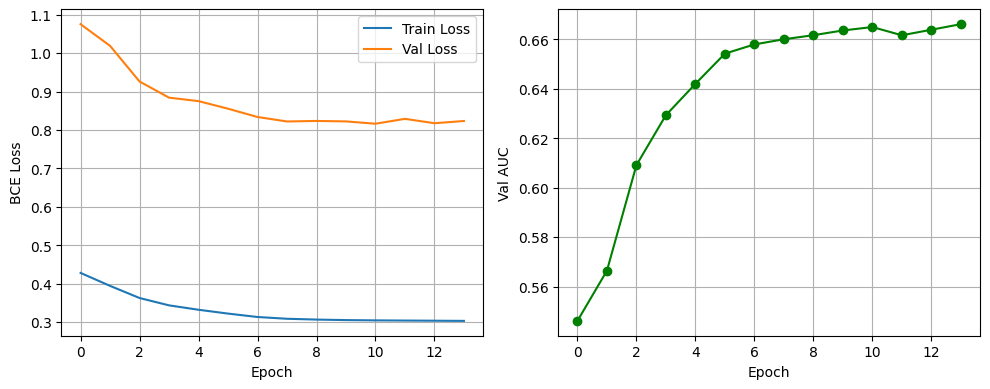


✅ Cell 4 Complete. MLP trained, evaluated, and saved for hybrid ensemble.


In [4]:
# 🚀 Cell 4: Training Execution, Early Stopping & Artifact Saving
import matplotlib.pyplot as plt
import time
import os

# 3. Hyperparameters & Initialization
# Note: Adjust these before re-running Cell 4 for ablation/tuning
EMBED_DIM = 64
HIDDEN_DIMS = [64, 32]  # 2 hidden layers as proposed
DROPOUT = 0.3
LR = 5e-4
EPOCHS = 20
PATIENCE = 3

model = MLP_CF(n_users, n_books, embed_dim=EMBED_DIM, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT).to(DEVICE)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters())}")
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# 4. Training Loop with Early Stopping
best_val_loss = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_model_wts = None

print(f"🚀 Starting MLP training on {DEVICE}...")
for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_auc = eval_epoch(model, val_loader, criterion, DEVICE)
    epoch_time = time.time() - start

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | Time: {epoch_time:.1f}s")

    # Inside the epoch loop, after computing val_loss & val_auc:
    if epoch % 5 == 0 or epoch == 1:
        rank_metrics = eval_ranking_metrics(
            model=model,
            train_df=train_imp,  # Use the implicit version with user_idx/book_idx
            val_df=val_imp,
            artifacts=artifacts,
            device=DEVICE,
            k_values=[5, 10],
            n_sample_users=500
        )
        # Format output cleanly
        p5, r5, n5 = rank_metrics['Precision@5'], rank_metrics['Recall@5'], rank_metrics['NDCG@5']
        p10, r10, n10 = rank_metrics['Precision@10'], rank_metrics['Recall@10'], rank_metrics['NDCG@10']
        print(f"   └─ Rank@5:  P={p5:.4f} | R={r5:.4f} | NDCG={n5:.4f}")
        print(f"   └─ Rank@10: P={p10:.4f} | R={r10:.4f} | NDCG={n10:.4f}")

    # Early stopping & checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"⏹️ Early stopping triggered at epoch {epoch}")
            break

# 5. Load Best Weights & Save Artifacts
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print("✅ Loaded best model weights.")

# Save for ensemble phase
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'mlp_cf_weights.pt'))
torch.save({
    'embed_dim': EMBED_DIM,
    'hidden_dims': HIDDEN_DIMS,
    'dropout': DROPOUT,
    'n_users': n_users,
    'n_books': n_books
}, os.path.join(MODEL_DIR, 'mlp_config.pt'))

# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('BCE Loss'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history['val_auc'], color='green', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Val AUC'); plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✅ Cell 4 Complete. MLP trained, evaluated, and saved for hybrid ensemble.")